In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [9]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
df.shape

(9568, 5)

In [11]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Convert data into Tensors
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [14]:
# TensorDataset & DataLoader
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

In [20]:
# define an ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # Output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [21]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

### Train The ANN

In [25]:
train_losses = [] # training losses
val_losses = [] # validation losses

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb => features of 1 batch
        # yb => labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # Forward prop.... predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # Backward prop... compute gradients
        optimizer.step() # params update

        running_loss += loss.item()  # loss is a tensor.. convert tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_losses = 0.0
    
    with  torch.no_grad():  # compute no gradients & save the memory
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
    
            running_val_losses += loss

    epoch_val_loss = running_val_losses / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ===> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

epoch 1/100 ===> train loss = 116257.92399088542 & val loss = 90338.78125
epoch 2/100 ===> train loss = 69398.79423828125 & val loss = 52569.7265625
epoch 3/100 ===> train loss = 41712.39537760417 & val loss = 33482.33984375
epoch 4/100 ===> train loss = 28037.860587565105 & val loss = 23810.634765625
epoch 5/100 ===> train loss = 20957.184521484374 & val loss = 18527.52734375
epoch 6/100 ===> train loss = 16724.260201009114 & val loss = 14834.673828125
epoch 7/100 ===> train loss = 13312.394950358073 & val loss = 11573.96484375
epoch 8/100 ===> train loss = 10131.401206461589 & val loss = 8558.396484375
epoch 9/100 ===> train loss = 7281.645336914063 & val loss = 5947.076171875
epoch 10/100 ===> train loss = 4919.169858805339 & val loss = 3936.772705078125
epoch 11/100 ===> train loss = 3255.2630294799806 & val loss = 2646.879638671875
epoch 12/100 ===> train loss = 2203.7629803975424 & val loss = 1843.3787841796875
epoch 13/100 ===> train loss = 1535.432445526123 & val loss = 1299.12

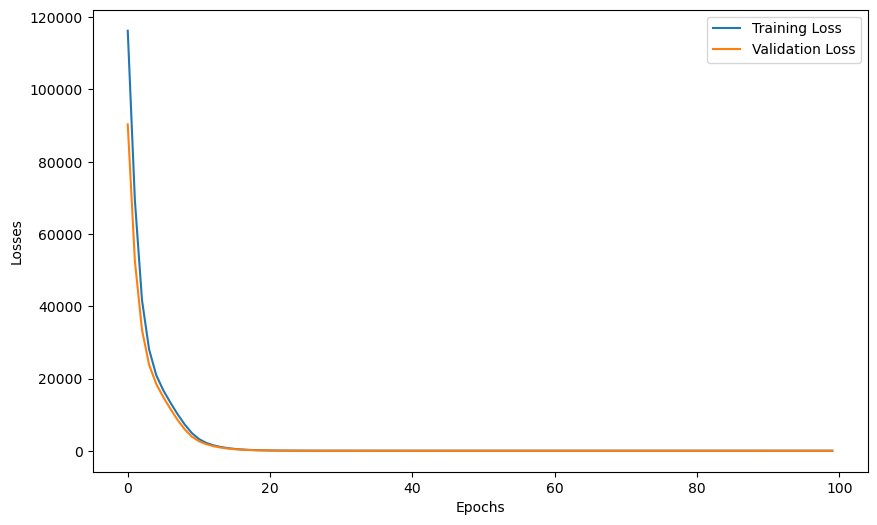

In [27]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize = (10, 6))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()